In [ ]:
import os
import numpy as np
from dotenv import load_dotenv
from scipy.signal import stft
from tqdm import tqdm
import matplotlib.pyplot as plt

from rfml_uav.drone_rf.consts import BUI, BUI_dict, FS
from rfml_uav.drone_rf.utils import get_segment_count

load_dotenv()

True

In [2]:
# Path of raw RF data
load_path = os.path.join(os.getenv("DATA_PATH"), "chunked")
save_path = os.path.join(os.getenv("DATA_PATH"), "STFT")
os.makedirs(save_path, exist_ok=True)

M = 512

In [3]:
def get_spectral_features(stft):
    f, _, Zxx = stft

    # Compute magnitude spectrum
    magnitude = np.abs(Zxx)

    spectral_flux = np.sum(np.diff(magnitude, axis=1)**2, axis=0)

    spectral_centroid = np.sum(f[:, None] * magnitude, axis=0) / np.sum(magnitude, axis=0)

    P = magnitude / np.sum(magnitude, axis=0)  # Normalize each column (time frame)    
    spectral_entropy = -np.sum(P * np.log2(P + np.finfo(float).eps), axis=0)  # Add epsilon to avoid log(0)

    return (spectral_centroid, spectral_flux, spectral_entropy)

def get_stft_data(bui: str):
    data = []
    N = get_segment_count(bui)

    for n in tqdm(range(N)):
        # Loading raw CSV files
        x_chunks = np.load(os.path.join(load_path, f"{bui}L_{n}.npz"))['arr_0']
        y_chunks = np.load(os.path.join(load_path, f"{bui}H_{n}.npz"))['arr_0']

        for i in range(len(x_chunks)):
            x_features = np.concat(get_spectral_features(stft(x_chunks[i], fs=FS, nperseg=M)))
            y_features = np.concat(get_spectral_features(stft(y_chunks[i], fs=FS, nperseg=M)))
            data.append(np.concat((x_features, y_features)))

    return np.array(data)

In [ ]:
for bui in BUI:
    data = get_stft_data(bui)
    np.savetxt(os.path.join(save_path, f"{bui}.csv"), data, delimiter=",")

## Visualizing STFT-based spectral features

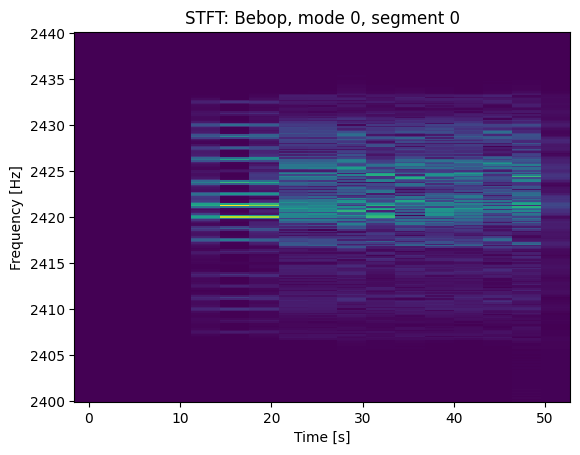

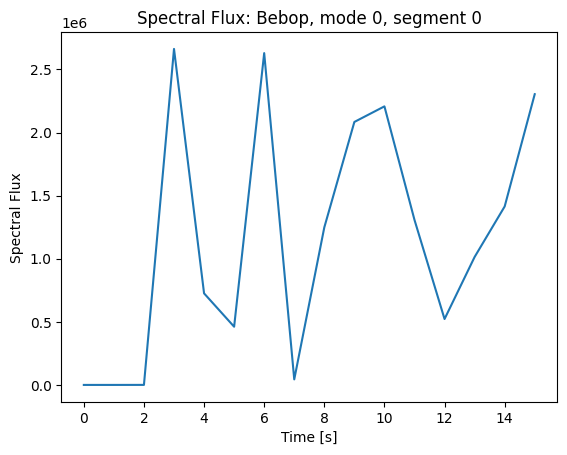

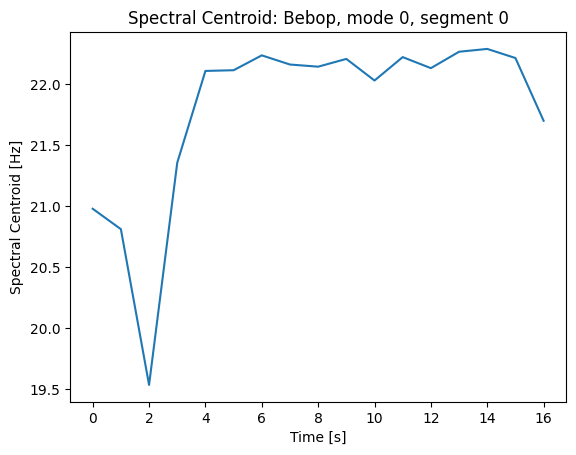

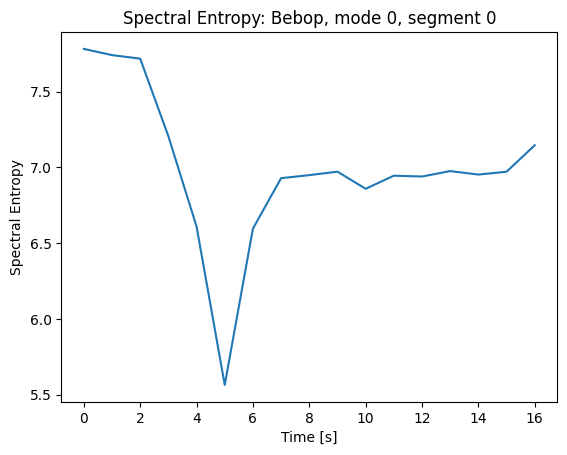

In [7]:
drone_type = "Bebop"
mode = 0
bui = BUI_dict[drone_type][mode]
n = 0
x = np.load(os.path.join(load_path, f"{bui}L_{n}.npz"))['arr_0'][1]
stft_x = stft(x, fs=FS, nperseg=M)
spectral_centroid, spectral_flux, spectral_entropy = get_spectral_features(stft_x)


f_stft, t_stft, Zxx = stft_x
# Plot spectral flux
plt.pcolormesh(t_stft, 2400 + f_stft, np.abs(Zxx))
plt.title(f'STFT: {drone_type}, mode {mode}, segment {n}')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [Hz]')
plt.show()

# Plot spectral flux
plt.plot(np.arange(spectral_flux.shape[0]), spectral_flux)
plt.title(f'Spectral Flux: {drone_type}, mode {mode}, segment {n}')
plt.xlabel('Time [s]')
plt.ylabel('Spectral Flux')
plt.show()

plt.plot(np.arange(spectral_centroid.shape[0]), spectral_centroid)
plt.title(f'Spectral Centroid: {drone_type}, mode {mode}, segment {n}')
plt.xlabel('Time [s]')
plt.ylabel('Spectral Centroid [Hz]')
plt.show()

# Plot spectral entropy
plt.plot(np.arange(spectral_entropy.shape[0]), spectral_entropy)
plt.title(f'Spectral Entropy: {drone_type}, mode {mode}, segment {n}')
plt.xlabel('Time [s]')
plt.ylabel('Spectral Entropy')
plt.show()

In [8]:
f, t, Zxx = stft(x, fs=FS, nperseg=M)
f.shape, t.shape, Zxx.shape

((257,), (17,), (257, 17))